# Multi-view Diffusion

In [1]:
pip install -r https://huggingface.co/spaces/dylanebert/multi-view-diffusion/raw/main/requirements.txt

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.4/159.4 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.1/85.1 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of accelerate to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of accelerate to determine which version is compatible with other requirements. This could take a while.
INFO: This is tak

In [2]:
# 1. Clear out any
!pip uninstall -y xformers torch torchvision torchaudio

# 2. Re-install the core with a specific link to the pre-built binaries
# This ensures PyTorch and xformers are downloaded as 'ready-to-use' files
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118
!pip install xformers==0.0.27 --index-url https://download.pytorch.org/whl/cu118 --no-deps

Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaudio 2.9.0+cu126
Uninstalling torchaudio-2.9.0+cu126:
  Successfully uninstalled torchaudio-2.9.0+cu126
Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 127.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 83.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 57.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 98.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.

## Pipeline

Create a multi-view diffusion pipeline. Diffusers doesn't officially support multi-view-diffusion, so we load a [custom pipeline](https://huggingface.co/docs/diffusers/v0.6.0/en/using-diffusers/custom_pipelines).

In [4]:
import torch
from diffusers import DiffusionPipeline

!pip install kiui

multi_view_diffusion_pipeline = DiffusionPipeline.from_pretrained(
    "dylanebert/multi-view-diffusion",
    custom_pipeline="dylanebert/multi-view-diffusion",
    torch_dtype=torch.float16,
    trust_remote_code=True,
).to("cuda")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 kB 4.7 MB/s eta 0:00:00


Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/563 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/460 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/601 [00:00<?, ?B/s]

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

Keyword arguments {'trust_remote_code': True} are not expected by MVDreamPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!
Expected types for unet: (<class 'diffusers_modules.local.dylanebert--multi-view-diffusion.3916e5568b2ee54ea8a81ce4961609158b2c464d.pipeline.MultiViewUNetModel'>,), got <class 'diffusers_modules.local.mv_unet.MultiViewUNetModel'>.


Load the input image.

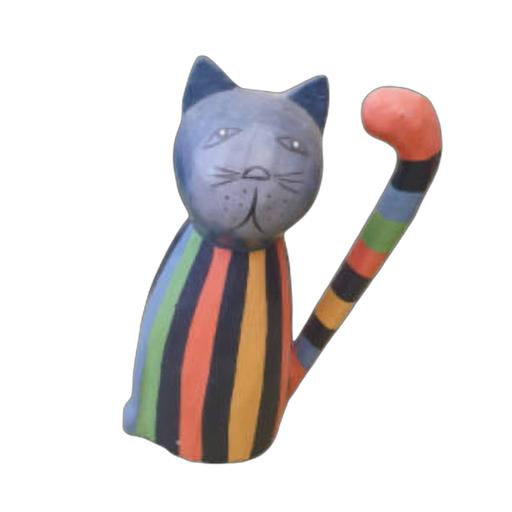

In [5]:
import requests
from PIL import Image
from io import BytesIO


image_url = "https://huggingface.co/datasets/dylanebert/3d-arena/resolve/main/inputs/images/a_cat_statue.jpg"
response = requests.get(image_url)
image = Image.open(BytesIO(response.content))
image

Pass the image through the multi-view diffusion pipeline.

  0%|          | 0/30 [00:00<?, ?it/s]

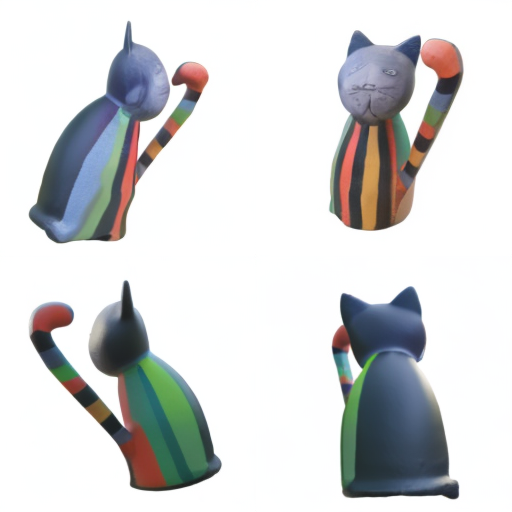

In [6]:
import numpy as np

def create_image_grid(images):
    images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

    width, height = images[0].size
    grid_img = Image.new("RGB", (2 * width, 2 * height))

    grid_img.paste(images[0], (0, 0))
    grid_img.paste(images[1], (width, 0))
    grid_img.paste(images[2], (0, height))
    grid_img.paste(images[3], (width, height))

    return grid_img

image = np.array(image, dtype=np.float32) / 255.0
images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

create_image_grid(images)

## Gradio Demo

In [7]:
import gradio as gr

def run(image):
  image = np.array(image, dtype=np.float32) / 255.0
  images = multi_view_diffusion_pipeline("", image, guidance_scale=5, num_inference_steps=30, elevation=0)

  images = [Image.fromarray((img * 255).astype("uint8")) for img in images]

  width, height = images[0].size
  grid_img = Image.new("RGB", (2 * width, 2 * height))

  grid_img.paste(images[0], (0, 0))
  grid_img.paste(images[1], (width, 0))
  grid_img.paste(images[2], (0, height))
  grid_img.paste(images[3], (width, height))

  return grid_img

demo = gr.Interface(fn=run, inputs="image", outputs="image")
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://abbc86ad3f38f09869.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [8]:
import numpy as np
import torch
from PIL import Image
import gradio as gr

def run(image):
    # Use inference_mode to save memory and speed up the T4 GPU
    with torch.inference_mode():
        # 1. Prepare image
        image = np.array(image, dtype=np.float32) / 255.0

        # 2. The Realism "Secret": Negative Prompt
        # This removes the '3D render' look and makes it look more like a photo
        neg_prompt = "cartoon, plastic, blurry, low resolution, 3d render, anime, sketch, matte, flat lighting"

        # 3. Fast generation
        # num_inference_steps=20 is the 'sweet spot' for speed on T4
        output_images = multi_view_diffusion_pipeline(
            prompt="",
            image=image,
            negative_prompt=neg_prompt,
            guidance_scale=7.5,
            num_inference_steps=20,
            elevation=0
        )

        # 4. Grid assembly
        pil_images = [Image.fromarray((img * 255).astype("uint8")) for img in output_images]
        w, h = pil_images[0].size
        grid = Image.new("RGB", (2 * w, 2 * h))
        grid.paste(pil_images[0], (0, 0))
        grid.paste(pil_images[1], (w, 0))
        grid.paste(pil_images[2], (0, h))
        grid.paste(pil_images[3], (w, h))

        return grid

# Launching the new, faster interface
demo = gr.Interface(
    fn=run,
    inputs="image",
    outputs="image",
    title="High-Speed Realistic Multi-View",
    description="Optimized for T4 GPUs: Uses fewer steps and negative prompting for photorealism."
)
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://92395d278fa3580e85.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [10]:
def run(image):
    with torch.inference_mode():
        # 1. Normalize image
        image = np.array(image, dtype=np.float32) / 255.0

        # 2. REALISM UPGRADE: The "Photorealistic" Prompts
        # We use a blank prompt because the image itself is the guide,
        # but we use a HEAVY negative prompt to kill the "AI look".
        prompt = "photorealistic, hyper-detailed fur, 8k uhd, high quality"
        neg_prompt = ("cartoon, 3d render, plastic, toy, blurry, low quality, "
                      "distorted, anime, sketch, matte, flat lighting, drawing, "
                      "illustration, cgi, monochrome")

        # 3. Optimized for Speed & Quality
        # guidance_scale=7.5 or higher makes details sharper.
        # 20 steps is fast but enough for high detail on a T4 GPU.
        output_images = multi_view_diffusion_pipeline(
            prompt=prompt,
            image=image,
            negative_prompt=neg_prompt,
            guidance_scale=12.0,     # Increased for sharper realism
            num_inference_steps=20,  # Fast but high-quality
            elevation=0
        )

        # 4. Grid assembly
        pil_images = [Image.fromarray((img * 255).astype("uint8")) for img in output_images]
        w, h = pil_images[0].size
        grid = Image.new("RGB", (2 * w, 2 * h))
        grid.paste(pil_images[0], (0, 0))
        grid.paste(pil_images[1], (w, 0))
        grid.paste(pil_images[2], (0, h))
        grid.paste(pil_images[3], (w, h))

        return grid